<a href="https://colab.research.google.com/github/JAHNAVI-BOOPATHY/deeplearning/blob/main/Character%20Recognition%20using%20LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training...
Epoch 1 Completed
Epoch 2 Completed
Training Finished


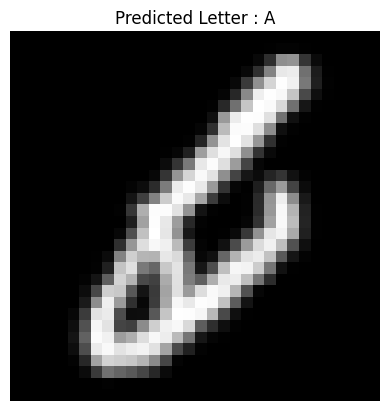

Actual Letter : A
Predicted Letter : A


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

# Load EMNIST Letters Dataset
train_dataset = datasets.EMNIST(
    root='./data',
    split='letters',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# LeNet Model
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,6,5),
            nn.Tanh(),
            nn.AvgPool2d(2),

            nn.Conv2d(6,16,5),
            nn.Tanh(),
            nn.AvgPool2d(2),

            nn.Conv2d(16,120,5),
            nn.Tanh()
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120,84),
            nn.Tanh(),
            nn.Linear(84,27)      # EMNIST Letters: labels 1-26
        )

    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x

model = LeNet5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# ---------------- Train ----------------
print("Training...")

for epoch in range(2):          # Increase to 5 for better accuracy
    model.train()

    for images,labels in train_loader:

        images=images.to(device)

        labels=(labels-1).to(device)    # Convert labels 1-26 to 0-25

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

    print("Epoch",epoch+1,"Completed")

print("Training Finished")

# ---------------- Prediction ----------------
letters="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

model.eval()

image,label=test_dataset[10]

display=image.squeeze().numpy()

image=image.unsqueeze(0).to(device)

with torch.no_grad():

    output=model(image)

    pred=torch.argmax(output,1).item()

plt.imshow(display,cmap='gray')
plt.title("Predicted Letter : "+letters[pred])
plt.axis("off")
plt.show()

print("Actual Letter :",letters[label-1])
print("Predicted Letter :",letters[pred])